Integrantes:
- Jose David Román
- Wendy Ortega
- Juan Cuadro

# Análisis Exploratorio de Datos

## Carga de Datos y Librerías

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import scipy.stats as stats
import warnings
warnings.filterwarnings('ignore')

# Configuración visual
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f9fa',
    'axes.grid': True,
    'grid.alpha': 0.4,
    'font.size': 11
})
PALETTE = ['#2196F3', '#E91E63', '#4CAF50', '#FF9800', '#9C27B0', '#00BCD4']

df = pd.read_excel('visceral_fat.xlsx')
print(f'Dimensiones del dataset: {df.shape[0]} filas × {df.shape[1]} columnas')
df.head()

Dimensiones del dataset: 133 filas × 8 columnas


,ethnicity,mean diastolic bp (mmhg),mean systolic bp (mmhg),central armellini fat (mm),pregnancies (number),bmi pregestational (kg/m),child birth weight (g),gestational dm
0,1,73.5,125.0,28.1,1.0,33.20,3840,0
1,0,75.5,112.0,43.1,1.0,21.50,2810,0
2,1,70.5,116.0,41.4,1.0,21.41,2455,0
3,0,92.5,167.0,39.6,4.0,55.36,3400,0
4,1,79.0,137.0,67.8,2.0,30.85,3930,1


## Identificación de Datos Ausentes

Se calcuremos el número y porcentaje de valores faltantes por columna.


In [6]:
# --- Identificación de valores faltantes ---
missing = df.isnull().sum()
missing_pct = (df.isnull().mean() * 100).round(2)
missing_df = pd.DataFrame({'Valores faltantes': missing, 'Porcentaje (%)': missing_pct})
missing_df = missing_df[missing_df['Valores faltantes'] > 0]

print('Variables con datos ausentes:')
print(missing_df.to_string())
print(f'\nTotal de filas con al menos un valor faltante: {df.isnull().any(axis=1).sum()}')

Variables con datos ausentes:
                           Valores faltantes  Porcentaje (%)
pregnancies (number)                       5            3.76
bmi pregestational (kg/m)                  1            0.75

Total de filas con al menos un valor faltante: 6


Se identificaron _**6 datos faltantes**_, los cuales equivalen al _**4.51% del total**_. Dado que se trata de variables biológicas con mediciones clínicas, decidimos no eliminar las filas para conservar el mayor número de datos disponibles. Por este motivo realizaremos _**imputación**_ de los valores ausentes.

Para determinar el estadístico de imputación adecuado (media o mediana), determinaremos la presencia de valores atípicos en cada variable afectada, pues una distribución con valores extremos hace que la media pueda ser un estimador sesgado, por lo que la mediana sería una mejor opción.


Estadísticas descriptivas de variables numéricas:


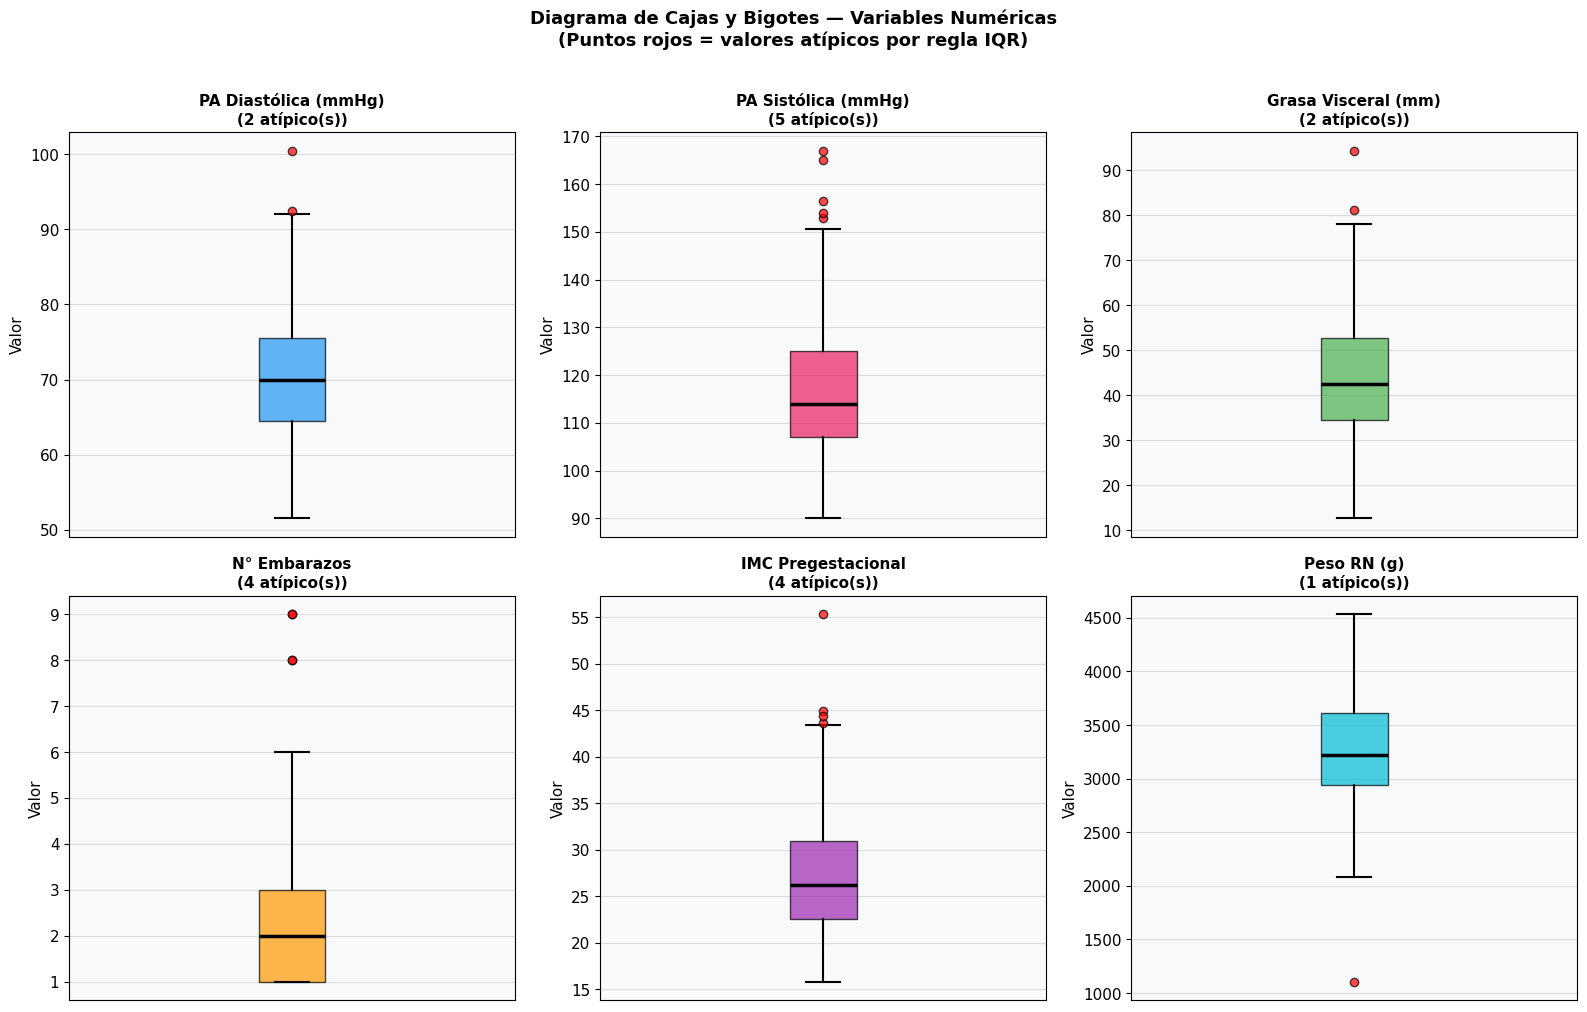


Resumen de valores atípicos (Método IQR):
  PA Diastólica (mmHg): 2 valores atípico(s)
  PA Sistólica (mmHg): 5 valores atípico(s)
  Grasa Visceral (mm): 2 valores atípico(s)
  N° Embarazos: 4 valores atípico(s)
  IMC Pregestacional: 4 valores atípico(s)
  Peso RN (g): 1 valores atípico(s)


In [7]:
num_vars = [
    'mean diastolic bp (mmhg)',
    'mean systolic bp (mmhg)',
    'central armellini fat (mm)',
    'pregnancies (number)',
    'bmi pregestational (kg/m)',
    'child birth weight (g)'
]

labels = {
    'mean diastolic bp (mmhg)': 'PA Diastólica (mmHg)',
    'mean systolic bp (mmhg)': 'PA Sistólica (mmHg)',
    'central armellini fat (mm)': 'Grasa Visceral (mm)',
    'pregnancies (number)': 'N° Embarazos',
    'bmi pregestational (kg/m)': 'IMC Pregestacional',
    'child birth weight (g)': 'Peso RN (g)'
}

desc = df[num_vars].describe().T
desc['CV (%)'] = (desc['std'] / desc['mean'] * 100).round(2)
desc['skewness'] = df[num_vars].skew().values
desc['kurtosis'] = df[num_vars].kurt().values
desc.index = [labels[c] for c in num_vars]
desc = desc[['count','mean','std','min','25%','50%','75%','max','CV (%)','skewness','kurtosis']].round(2)
desc.columns = ['n','Media','DE','Mín','Q1','Mediana','Q3','Máx','CV (%)','Asimetría','Curtosis']
print('Estadísticas descriptivas de variables numéricas:')

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

outlier_summary = {}

for i, col in enumerate(num_vars):
    ax = axes[i]
    data = df[col].dropna()
    
    bp = ax.boxplot(data, patch_artist=True,
                    boxprops=dict(facecolor=PALETTE[i], alpha=0.7),
                    medianprops=dict(color='black', linewidth=2.5),
                    whiskerprops=dict(linewidth=1.5),
                    capprops=dict(linewidth=1.5),
                    flierprops=dict(marker='o', markerfacecolor='red', markersize=6, alpha=0.7))
    
    # Cálculo IQR
    Q1, Q3 = data.quantile(0.25), data.quantile(0.75)
    IQR = Q3 - Q1
    outliers = data[(data < Q1 - 1.5*IQR) | (data > Q3 + 1.5*IQR)]
    outlier_summary[labels[col]] = len(outliers)

    ax.set_title(f'{labels[col]}\n({len(outliers)} atípico(s))', fontsize=11, fontweight='bold')
    ax.set_xticks([])
    ax.set_ylabel('Valor')

plt.suptitle('Diagrama de Cajas y Bigotes — Variables Numéricas\n(Puntos rojos = valores atípicos por regla IQR)', 
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nResumen de valores atípicos (Método IQR):')
for var, n in outlier_summary.items():
    print(f'  {var}: {n} valores atípico(s)')
    

Las variables `ethnicity` y `gestational dm` se excluyen del análisis de valores atípicos porque son _**variables categóricas binarias**_ (solo toman dos valores posibles), por lo que los criterios estadísticos de outliers no aplican.

Las variables con datos faltantes son `pregnancies (number)` y `bmi pregestational (kg/m)`. Para cada una se evalúa si los valores atípicos corresponden a errores de medición o a valores clínicamente posibles:

- `pregnancies (number)`: Los valores extremos detectados (multíparas con alto número de gestaciones) son clínicamente posibles.
- `bmi pregestational (kg/m)`: Los valores extremos en ambos extremos (bajo peso severo u obesidad mórbida) son **clínicamente posibles**.

Dado que ambas variables presentan valores atípicos extremos pero válidos, se utilizará la _**mediana**_ como estadístico de imputación, ya que es una mejor opción frente a la influencia de valores extremos que la media.

Dataset después de la imputación por la mediana. Los valores faltantes en `pregnancies (number)` y `bmi pregestational (kg/m)` fueron reemplazados por la mediana de cada columna calculada sobre los datos disponibles. El dataset resultante queda sin valores ausentes y se guarda como `visceral_fat_clean.xlsx`.

In [8]:
df_impt = df.copy()

for col in ['pregnancies (number)', 'bmi pregestational (kg/m)']:
    median_val = df_impt[col].median()
    n_imputed = df_impt[col].isnull().sum()
    df_impt[col] = df_impt[col].fillna(median_val)
    print(f'  {col}: {n_imputed} valores imputados con mediana = {median_val:.2f}')

print(f'\nValores faltantes después de imputación: {df_impt.isnull().sum().sum()}')
print(f'Dimensiones finales del dataset limpio: {df_impt.shape}')

# Guardar dataset imputado
df_impt.to_excel('visceral_fat_clean.xlsx', index=False)
print('\n✔ Archivo "visceral_fat_clean.xlsx" guardado exitosamente.')

  pregnancies (number): 5 valores imputados con mediana = 2.00
  bmi pregestational (kg/m): 1 valores imputados con mediana = 26.26

Valores faltantes después de imputación: 0
Dimensiones finales del dataset limpio: (133, 8)

✔ Archivo "visceral_fat_clean.xlsx" guardado exitosamente.


## Distribución de las Variables Numéricas

Para evaluar normalidad se aplicaremos la prueba de _**Kolmogorov-Smirnov con corrección de Lilliefors**_. Esta variante es la apropiada cuando los parámetros poblacionales (media y desviación estándar) no se conocen de antemano y deben estimarse desde los propios datos. Esta prueba se elige sobre Shapiro-Wilk porque el tamaño de la muestra es mayor a 50.

Para cada variable graficamos:
- Histograma de los datos
- Un histograma con la curva de densidad estimada (KDE)
- La distribución normal teórica


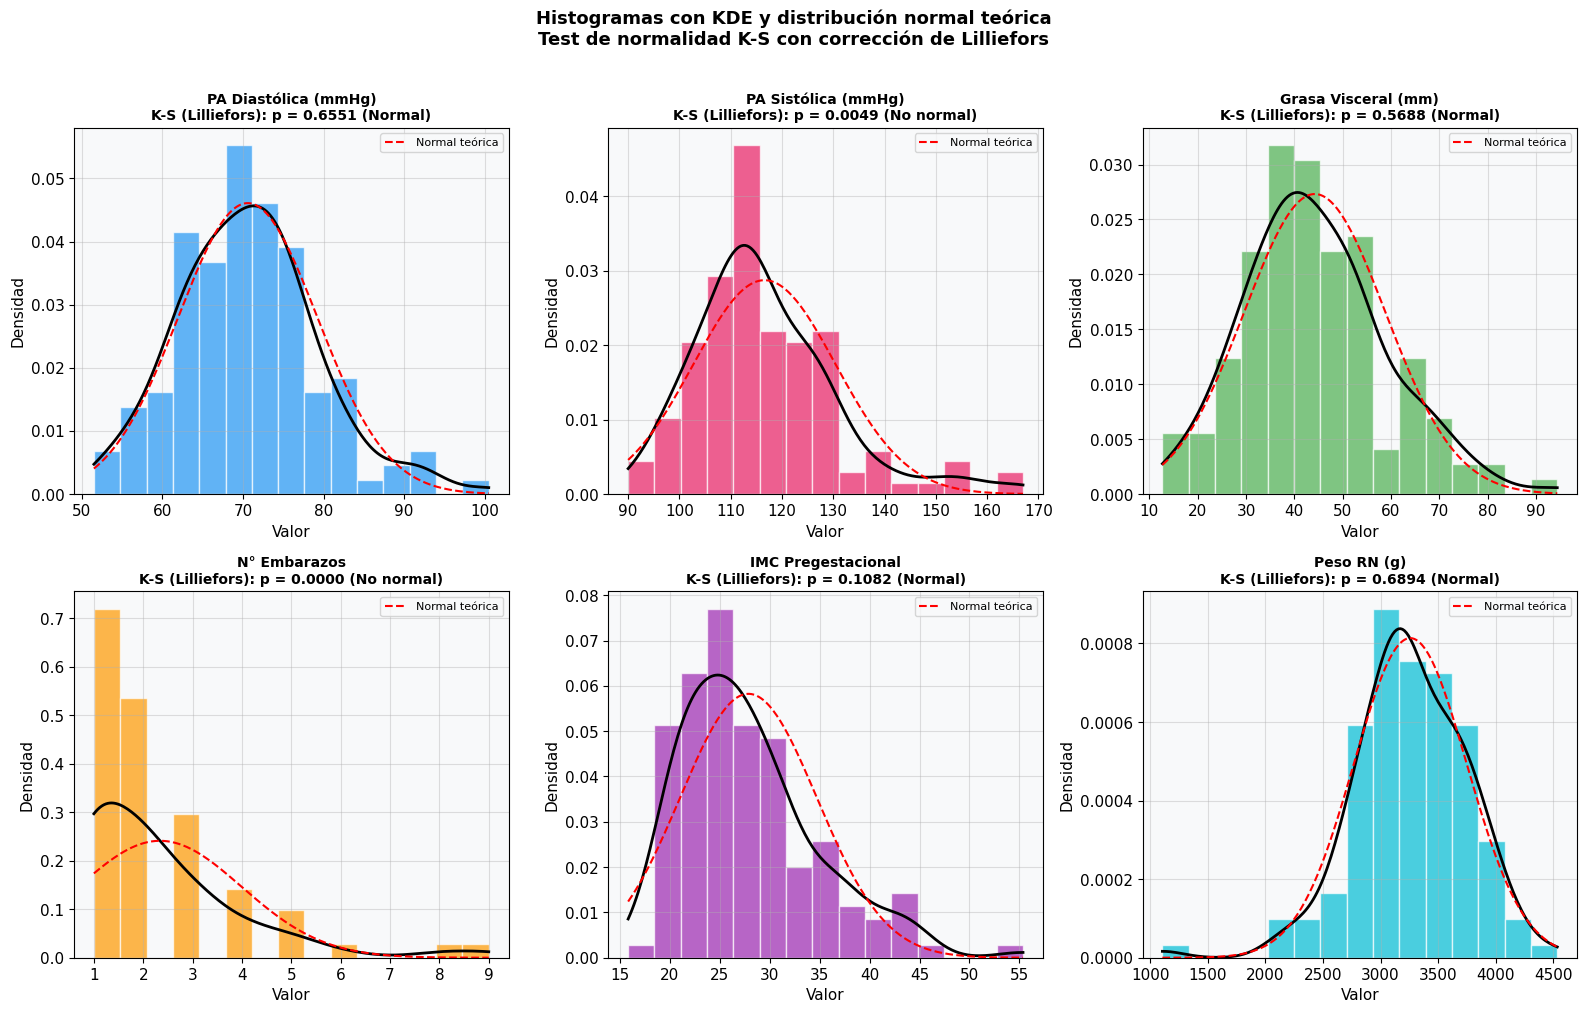

Resultados Test K-S con corrección de Lilliefors (H0: Distribucíon Normal; rechazo si p < 0.05):
                           D  p-valor            Conclusión
PA Diastólica (mmHg)  0.0624   0.6551     ✔ Normal (p>0.05)
PA Sistólica (mmHg)   0.1489   0.0049  ✘ No normal (p<0.05)
Grasa Visceral (mm)   0.0669   0.5688     ✔ Normal (p>0.05)
N° Embarazos          0.2504   0.0000  ✘ No normal (p<0.05)
IMC Pregestacional    0.1034   0.1082     ✔ Normal (p>0.05)
Peso RN (g)           0.0606   0.6894     ✔ Normal (p>0.05)


In [9]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

ks_results = {}

for i, col in enumerate(num_vars):
    ax = axes[i]
    data = df_impt[col].dropna()
    
    # Histograma + curva KDE
    ax.hist(data, bins=15, color=PALETTE[i], alpha=0.7, edgecolor='white', density=True)
    
    # KDE via scipy
    kde = stats.gaussian_kde(data)
    x_range = np.linspace(data.min(), data.max(), 200)
    ax.plot(x_range, kde(x_range), color='black', linewidth=2)
    
    # Curva normal teórica
    mu, sigma = data.mean(), data.std()
    ax.plot(x_range, stats.norm.pdf(x_range, mu, sigma), 'r--', linewidth=1.5, label='Normal teórica')
    
    # Test K-S con corrección de Lilliefors
    # Se estandariza la variable y se compara contra N(0,1).
    # Equivale a Lilliefors; apropiado para n > 50 cuando
    # los parámetros se estiman desde los propios datos.
    z_data = (data - mu) / sigma
    #stat, p = stats.kstest(z_data, 'norm')
    stat, p = stats.kstest(z_data, 'norm', args=(np.mean(z_data), np.std(z_data)))

    ks_results[labels[col]] = {'D': round(stat, 4), 'p-valor': round(p, 4)}
    normal_label = 'Normal' if p > 0.05 else 'No normal'
    
    ax.set_title(f'{labels[col]}\nK-S (Lilliefors): p = {p:.4f} ({normal_label})', fontsize=10, fontweight='bold')
    ax.set_xlabel('Valor')
    ax.set_ylabel('Densidad')
    ax.legend(fontsize=8)

plt.suptitle('Histogramas con KDE y distribución normal teórica\nTest de normalidad K-S con corrección de Lilliefors',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('histogramas.png', dpi=150, bbox_inches='tight')
plt.show()

print('Resultados Test K-S con corrección de Lilliefors (H0: Distribucíon Normal; rechazo si p < 0.05):')
ks_df = pd.DataFrame(ks_results).T
ks_df['Conclusión'] = ks_df['p-valor'].apply(lambda p: '✔ Normal (p>0.05)' if p > 0.05 else '✘ No normal (p<0.05)')
print(ks_df.to_string())

## Nivel de Variabilidad

Ahora calcularemos el _**Coeficiente de Variación (CV)**_ para cada variable numérica. El CV expresa la dispersión relativa como porcentaje de la media, lo que permite comparar la variabilidad de las variables. Los rangos de clasificación utilizados son: 
- **CV < 15%** → variabilidad baja
- **15% ≤ CV < 30%** → variabilidad moderada
- **CV ≥ 30%** → variabilidad alta.


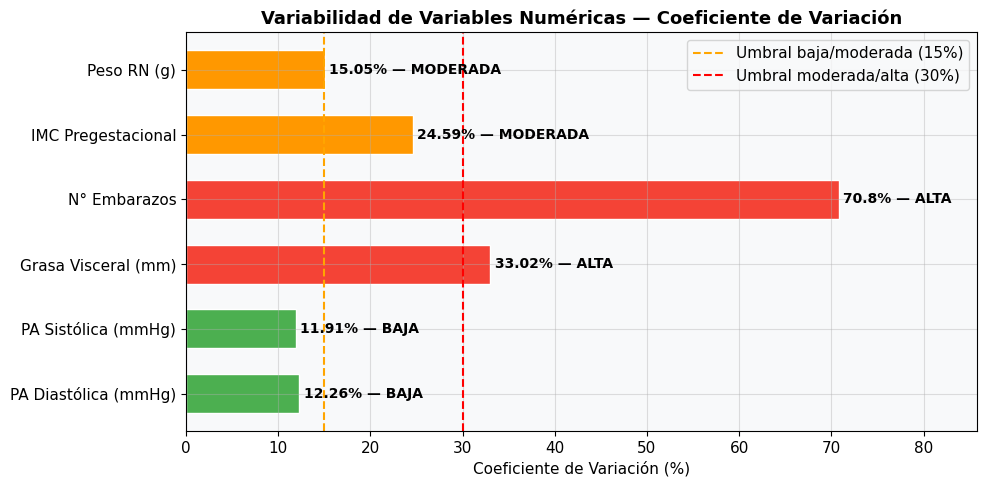

                     CV (%)     Nivel
PA Diastólica (mmHg)  12.26      BAJA
PA Sistólica (mmHg)   11.91      BAJA
Grasa Visceral (mm)   33.02      ALTA
N° Embarazos           70.8      ALTA
IMC Pregestacional    24.59  MODERADA
Peso RN (g)           15.05  MODERADA


In [10]:
cv_data = {}
for col in num_vars:
    data = df_impt[col]
    cv = (data.std() / data.mean()) * 100
    if cv < 15:
        nivel = 'BAJA'
        color = '#4CAF50'
    elif cv < 30:
        nivel = 'MODERADA'
        color = '#FF9800'
    else:
        nivel = 'ALTA'
        color = '#F44336'
    cv_data[labels[col]] = {'CV (%)': round(cv, 2), 'Nivel': nivel, 'Color': color}

cv_df = pd.DataFrame(cv_data).T

# Gráfico
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(cv_df.index, cv_df['CV (%)'].astype(float), color=cv_df['Color'], edgecolor='white', height=0.6)

for bar, (idx, row) in zip(bars, cv_df.iterrows()):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f"{row['CV (%)']}% — {row['Nivel']}", va='center', fontweight='bold', fontsize=10)

ax.axvline(15, color='orange', linestyle='--', linewidth=1.5, label='Umbral baja/moderada (15%)')
ax.axvline(30, color='red', linestyle='--', linewidth=1.5, label='Umbral moderada/alta (30%)')
ax.set_xlabel('Coeficiente de Variación (%)')
ax.set_title('Variabilidad de Variables Numéricas — Coeficiente de Variación', fontsize=13, fontweight='bold')
ax.legend()
ax.set_xlim(0, max(cv_df['CV (%)'].astype(float)) + 15)
plt.tight_layout()
plt.savefig('variabilidad_cv.png', dpi=150, bbox_inches='tight')
plt.show()

print(cv_df[['CV (%)', 'Nivel']].to_string())

El _**Coeficiente de Variación**_ permite comparar la dispersión relativa entre variables con distintas unidades. 

| Variable | Nivel | Implicaciones |
|---|---|---|
| PA Diastólica | **Baja** | La mayoría de las pacientes presenta valores similares, lo que indica una población relativamente homogénea en presión diastólica |
| PA Sistólica | **Baja** | Existe variabilidad esperada por la presencia de casos hipertensivos |
| Grasa Visceral | **Alta** | Refleja la diversidad en composición corporal relacionada con el IMC pregestacional |
| N° Embarazos | **Alta** | Muestra una población heterogénea: desde madres con un hijo hasta madres con muchos hijos |
| IMC Pregestacional | **Moderada** | Gran diversidad nutricional; abarca desde bajo peso hasta obesidad |
| Peso RN | **Moderada** | El peso neonatal es relativamente homogéneo, pero pasa el rango de _**cv<15%**_ |

_**Implicación estadística:**_ Las variables con alta variabilidad (grasa visceral, número de embarazos) y moderada (IMC, peso RN) requieren mayor atención al seleccionar pruebas estadísticas y pueden necesitar transformaciones para cumplir supuestos de normalidad en análisis paramétricos.


## Correlación entre Variables Numéricas

Construimos una **matriz de correlación de Spearman** entre todas las variables numéricas. Para determinar el coeficiente de Spearman (en lugar de Pearson) debido a que algunas variables presentaron distribuciones no normales según el test K-S con Lilliefors. Spearman evalúa correlaciones monotónicas sin asumir linealidad ni normalidad, siendo más adecuado para estas distribuciones.


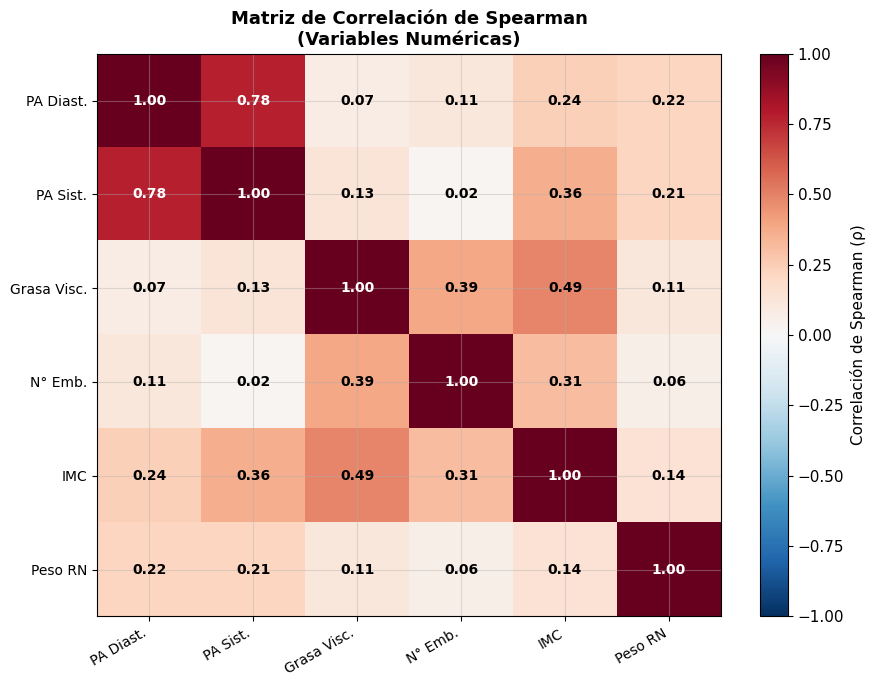

In [11]:
# Matriz de correlación de Spearman (preferida por distribuciones no normales)
corr_matrix = df_impt[num_vars].corr(method='spearman')
short_labels = ['PA Diast.', 'PA Sist.', 'Grasa Visc.', 'N° Emb.', 'IMC', 'Peso RN']

fig, ax = plt.subplots(figsize=(9, 7))
corr_vals = corr_matrix.values
im = ax.imshow(corr_vals, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
plt.colorbar(im, ax=ax, label='Correlación de Spearman (ρ)')

ax.set_xticks(range(len(short_labels)))
ax.set_yticks(range(len(short_labels)))
ax.set_xticklabels(short_labels, rotation=30, ha='right', fontsize=10)
ax.set_yticklabels(short_labels, fontsize=10)

for i in range(len(short_labels)):
    for j in range(len(short_labels)):
        val = corr_vals[i, j]
        color = 'white' if abs(val) > 0.5 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=10, fontweight='bold', color=color)

ax.set_title('Matriz de Correlación de Spearman\n(Variables Numéricas)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('correlacion_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

### Interpretación de las correlaciones más relevantes

#### Correlación fuerte
**PA Diastólica ↔ PA Sistólica (ρ ≈ 0.78)**  
Es una correlación fisiológicamente esperada, pues ambas presiones comparten determinantes comunes como la resistencia vascular periférica y el volumen sistólico. En el embarazo, condiciones como la preeclampsia elevan simultáneamente ambos componentes *(Magee et al., 2014; ACOG, 2020)*.

#### Correlación moderada
- **Grasa Visceral ↔ IMC Pregestacional (ρ ≈ 0.49)**  
Esta correlación indica que, a mayor Índice de Masa Corporal hay una tendencia a tener una mayor acumulación de grasa visceral.
- **PA Sistólica ↔ IMC (ρ ≈ 0.36)**
     Se observa que el peso corporal (medido por IMC) tiene un impacto más notable en la presión sistólica que en la diastólica, con el cual tiene una correlación menor de 0.24.
- **Número de Embarazos ↔ Grasa Visceral (ρ ≈ 0.39)**
     Sugiere que la paridad (cantidad de embarazos) podría estar asociada con un aumento en la grasa visceral en esta muestra.

#### Correlación moderada
- Peso del Recién Nacido: Es la variable con las correlaciones más bajas de la tabla. Su relación más "alta" es con la PA Diastólica (0.22) y la PA Sistólica (0.21). Esto sugiere que, en este conjunto de datos, el peso del bebé no depende fuertemente del IMC de la madre o de su cantidad de embarazos previos.
- N° de Embarazos y PA Sistólica (ρ ≈ 0.02): Es una correlación prácticamente nula. Indica que no hay una relación directa entre cuántos hijos ha tenido una persona y su presión arterial sistólica actual.

---

#### Referencias
- Magee, L. A., Pels, A., Helewa, M., et al. (2014). Diagnosis, evaluation, and management of the hypertensive disorders of pregnancy. *Pregnancy Hypertension*, 4(2), 105–145.



## ariables Categóricas

Analizaremos la distribución de frecuencias de las dos variables categóricas binarias del dataset: `ethnicity` (etnia) y `gestational dm` (diabetes mellitus gestacional). Para cada una tenemos una grafica de barras con la frecuencia absoluta y el porcentaje correspondiente, facilitando la interpretación del balance entre categorías.


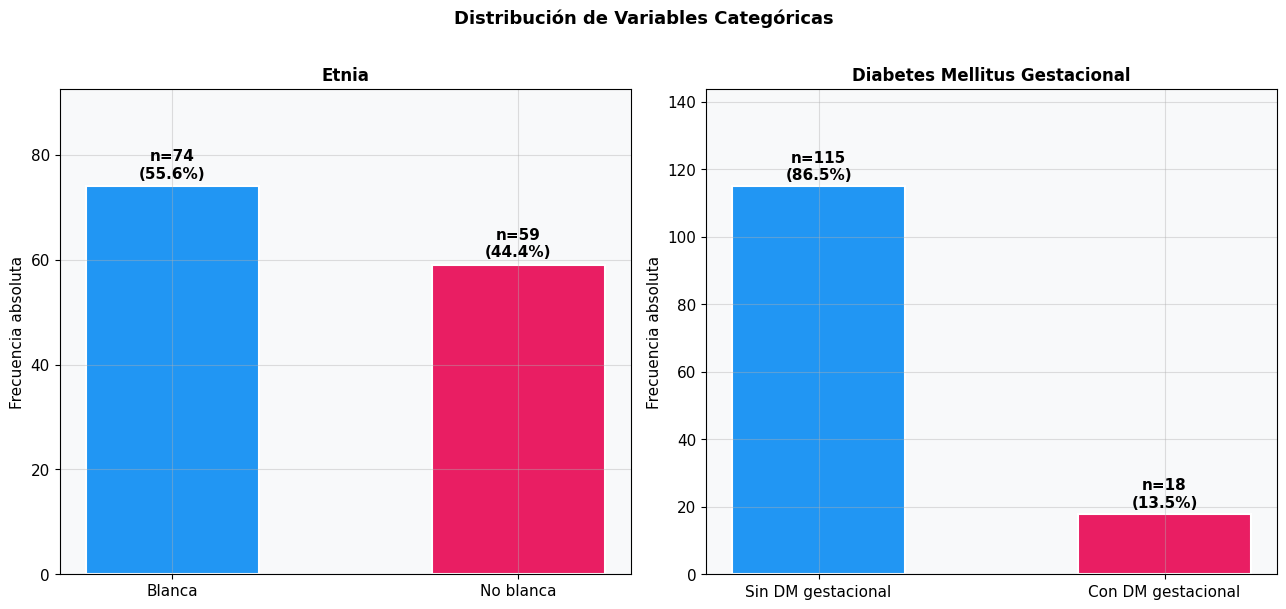

In [12]:
cat_vars = ['ethnicity', 'gestational dm']
cat_labels = {'ethnicity': 'Etnia', 'gestational dm': 'Diabetes Mellitus Gestacional'}
cat_value_labels = {
    'ethnicity': {0: 'Blanca', 1: 'No blanca'},
    'gestational dm': {0: 'Sin DM gestacional', 1: 'Con DM gestacional'}
}

fig, axes = plt.subplots(1, 2, figsize=(13, 6))

for i, col in enumerate(cat_vars):
    ax = axes[i]
    counts = df_impt[col].value_counts().sort_index()
    pcts = (counts / counts.sum() * 100).round(1)
    labels_plot = [cat_value_labels[col][k] for k in counts.index]
    
    bars = ax.bar(labels_plot, counts.values, color=[PALETTE[0], PALETTE[1]], edgecolor='white', linewidth=1.5, width=0.5)
    for bar, n, pct in zip(bars, counts.values, pcts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'n={n}\n({pct}%)', ha='center', va='bottom', fontweight='bold', fontsize=11)
    
    ax.set_title(cat_labels[col], fontsize=12, fontweight='bold')
    ax.set_ylabel('Frecuencia absoluta')
    ax.set_ylim(0, max(counts.values) * 1.25)

plt.suptitle('Distribución de Variables Categóricas', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('categoricas_barras.png', dpi=150, bbox_inches='tight')
plt.show()

### Interpretación de las variables categóricas

#### Variable 1: Etnia (`ethnicity`)

Variable **binaria nominal** (sin orden entre categorías).

- **Blanca (0):** 74 pacientes → 55.6% de la muestra  
- **No blanca (1):** 59 pacientes → 44.4% de la muestra

La distribución es **relativamente equilibrada**, lo cual favorece los análisis comparativos entre grupos. La diversidad étnica es clínicamente relevante porque la distribución de grasa visceral y el riesgo metabólico pueden variar según el origen étnico, incluso con IMC similar *(Garvey et al., 2014)*.

---

#### Variable 2: Diabetes Mellitus Gestacional (`gestational dm`)

Variable **binaria nominal**.

- **Sin DM gestacional (0):** 115 pacientes → 86.5% de la muestra  
- **Con DM gestacional (1):** 18 pacientes → 13.5% de la muestra

La prevalencia del **13.5%** es coherente con las tasas reportadas para poblaciones con seguimiento metabólico activo (5–14% según criterios diagnósticos) *(American Diabetes Association, 2021)*. La distribución es **marcadamente desbalanceada**, algo esperado para una condición clínica de baja prevalencia. Este desbalance debe tenerse en cuenta en análisis comparativos para garantizar suficiente potencia estadística.

---

#### Referencias adicionales
- American Diabetes Association (2021). *Standards of Medical Care in Diabetes — Gestational Diabetes*. Diabetes Care, 44(Suppl 1), S200–S210.
- Garvey, W. T., Mechanick, J. I., Brett, E. M., et al. (2014). *AACE guidelines for management of dyslipidemia and prevention of atherosclerosis*. Endocrine Practice, 20(S1), 1–33.


# Análisis Comparativo: 

## Mujeres Blancas vs. No Blancas (Etnia)

Dividimos el dataset en dos subgrupos según la variable `ethnicity` para comparar el comportamiento de las variables numéricas entre mujeres blancas (0) y no blancas (1).

In [33]:
df_blancas    = df_impt[df_impt['ethnicity'] == 0].reset_index(drop=True)
df_no_blancas = df_impt[df_impt['ethnicity'] == 1].reset_index(drop=True)

print('Grupo BLANCA   :', df_blancas.shape[0], 'pacientes')
print('Grupo NO BLANCA:', df_no_blancas.shape[0], 'pacientes')

Grupo BLANCA   : 74 pacientes
Grupo NO BLANCA: 59 pacientes


In [34]:
desc = df_blancas[num_vars].describe().T
desc['CV (%)'] = (desc['std'] / desc['mean'] * 100).round(2)
desc['skewness'] = df_blancas[num_vars].skew().values
desc['kurtosis'] = df_blancas[num_vars].kurt().values
desc.index = [labels[c] for c in num_vars]
desc = desc[['count','mean','std','min','25%','50%','75%','max','CV (%)','skewness','kurtosis']].round(2)
desc.columns = ['n','Media','DE','Mín','Q1','Mediana','Q3','Máx','CV (%)','Asimetría','Curtosis']
print('Estadísticas descriptivas de variables numéricas MUJERES BLANCAS:')
desc

Estadísticas descriptivas de variables numéricas MUJERES BLANCAS:


,n,Media,DE,Mín,Q1,Mediana,Q3,Máx,CV (%),Asimetría,Curtosis
PA Diastólica (mmHg),74.0,72.79,8.68,56.50,67.12,72.00,76.75,100.50,11.93,0.82,0.84
PA Sistólica (mmHg),74.0,120.55,14.22,96.50,112.00,116.50,126.38,167.00,11.80,1.29,2.14
Grasa Visceral (mm),74.0,45.70,16.44,12.70,33.72,43.05,54.68,94.40,35.97,0.45,0.09
N° Embarazos,74.0,2.38,1.78,1.00,1.00,2.00,3.00,9.00,74.86,1.86,3.61
IMC Pregestacional,74.0,29.00,7.56,19.02,23.53,27.18,32.30,55.36,26.07,1.08,1.01
Peso RN (g),74.0,3270.08,571.98,1105.00,2937.00,3242.50,3653.75,4534.00,17.49,-0.77,1.76


In [35]:
desc = df_no_blancas[num_vars].describe().T
desc['CV (%)'] = (desc['std'] / desc['mean'] * 100).round(2)
desc['skewness'] = df_no_blancas[num_vars].skew().values
desc['kurtosis'] = df_no_blancas[num_vars].kurt().values
desc.index = [labels[c] for c in num_vars]
desc = desc[['count','mean','std','min','25%','50%','75%','max','CV (%)','skewness','kurtosis']].round(2)
desc.columns = ['n','Media','DE','Mín','Q1','Mediana','Q3','Máx','CV (%)','Asimetría','Curtosis']
print('Estadísticas descriptivas de variables numéricas MUJERES BLANCAS:')
desc

Estadísticas descriptivas de variables numéricas MUJERES BLANCAS:


,n,Media,DE,Mín,Q1,Mediana,Q3,Máx,CV (%),Asimetría,Curtosis
PA Diastólica (mmHg),59.0,67.84,7.86,51.50,62.25,68.00,74.00,83.50,11.59,-0.12,-0.71
PA Sistólica (mmHg),59.0,111.59,11.77,90.00,103.00,111.50,115.75,150.50,10.55,0.93,1.43
Grasa Visceral (mm),59.0,42.39,11.80,17.70,35.85,41.70,49.60,74.50,27.84,0.23,0.21
N° Embarazos,59.0,2.29,1.50,1.00,1.00,2.00,3.00,9.00,65.46,1.91,5.75
IMC Pregestacional,59.0,26.43,5.58,15.81,22.04,26.02,30.04,41.33,21.10,0.60,-0.04
Peso RN (g),59.0,3241.86,367.32,2455.00,3030.00,3205.00,3475.00,4220.00,11.33,0.34,-0.03


## Paso 1 · Selección de la prueba estadística

Considerando las características del problema, se selecciona la **prueba t para dos muestras** como prueba paramétrica de referencia.

**Justificación:**
- Se comparan **dos grupos independientes** (blancas vs. no blancas); cada paciente pertenece a uno solo.
- Las variables dependientes son **cuantitativas continuas**.
- Los supuestos que se verificarán son: **normalidad, homocedasticidad e independencia**.

En caso de que los supuestos de normalidad no se cumplan ni tras transformación, la alternativa no paramétrica que corrresponde es la **prueba U de Mann-Whitney**.

---

## Paso 2 · Planteamiento de hipótesis

Para cada variable numérica $X$, las hipótesis son:

$$H_0: \mu_{\text{Blanca}} = \mu_{\text{No Blanca}} \quad \text{(las medias son iguales entre grupos étnicos)}$$

$$H_1: \mu_{\text{Blanca}} \neq \mu_{\text{No Blanca}} \quad \text{(las medias difieren entre grupos étnicos)}$$

Nivel de significancia: $\alpha = 0.05$

---

# Variable 1: PA Diastólica (mmHg) — Comparación por Etnia

## Paso 3 · Verificación de supuestos

### 3a. Normalidad — Test K-S con corrección de Lilliefors

Se aplica el test K-S con corrección de Lilliefors a cada grupo por separado, dado que $n > 50$ en ambos casos.

- **H₀:** La distribución de PA Diastólica es normal en el grupo
- **H₁:** La distribución no es normal


In [36]:
# Se usa K-S con Lilliefors porque n > 50 en ambos grupos (indicado en la tabla)
g1 = df_blancas['mean diastolic bp (mmhg)'].values
g2 = df_no_blancas['mean diastolic bp (mmhg)'].values

ks_stat1, ks_p1 = stats.kstest(g1, 'norm', args=(np.mean(g1), np.std(g1)))
ks_stat2, ks_p2 = stats.kstest(g2, 'norm', args=(np.mean(g2), np.std(g2)))

print('K-S Lilliefors — PA Diastólica')
print(f'  Grupo Blanca   : stat={ks_stat1:.4f}, p={ks_p1:.4f} →', '✔ Normal' if ks_p1>=0.05 else '✘ No normal')
print(f'  Grupo No Blanca: stat={ks_stat2:.4f}, p={ks_p2:.4f} →', '✔ Normal' if ks_p2>=0.05 else '✘ No normal')

K-S Lilliefors — PA Diastólica
  Grupo Blanca   : stat=0.0981, p=0.4461 → ✔ Normal
  Grupo No Blanca: stat=0.0712, p=0.9051 → ✔ Normal


### 3b. Homocedasticidad — Levene


**H₀:** Las varianzas de ambos grupos son iguales (homocedasticidad)  
**H₁:** Las varianzas son diferentes (heterocedasticidad)

In [37]:
levene_stat, levene_p = stats.levene(g1, g2)
print('Levene — PA Diastólica')
print(f'  stat={levene_stat:.4f}, p={levene_p:.4f} →', '✔ Homocedástica' if levene_p>=0.05 else '✘ Heterocedástica')

Levene — PA Diastólica
  stat=0.0104, p=0.9191 → ✔ Homocedástica


### Paso 4 · Aplicar prueba t para dos muestras

In [38]:
datos1 = df_blancas['mean diastolic bp (mmhg)']
datos2 = df_no_blancas['mean diastolic bp (mmhg)']

t_stat, p_value = stats.ttest_ind(datos1, datos2)
print('Prueba t — PA Diastólica | Etnia')
print(f'  t = {t_stat:.4f},  p = {p_value:.4f}')
print('  →', 'RECHAZA H0: por lo tanto hay diferencia significativa' if p_value<0.05 else 'NO SE RECHAZA H0: por lo tanto no hay diferencia significativa')

Prueba t — PA Diastólica | Etnia
  t = 3.4059,  p = 0.0009
  → RECHAZA H0: por lo tanto hay diferencia significativa


### Conclusión — PA Diastólica | Etnia
Con p < 0.05 se rechaza H₀. **Existe diferencia estadísticamente significativa** en la PA Diastólica entre mujeres blancas y no blancas en esta muestra.

---
# ── VARIABLE 2: PA Sistólica (mmHg) ── Etnia
## Paso 3 · Verificar supuestos
### 3a. Normalidad — K-S Lilliefors

**H₀:** La distribución de PA Sistólica es normal  
**H₁:** La distribución de PA Sistólica no es normal

*(La distribución global ya fue identificada como no normal; ahora se corrobora por grupo)*

In [39]:
g1 = df_blancas['mean systolic bp (mmhg)'].values
g2 = df_no_blancas['mean systolic bp (mmhg)'].values

ks_stat1, ks_p1 = stats.kstest(g1, 'norm', args=(np.mean(g1), np.std(g1)))
ks_stat2, ks_p2 = stats.kstest(g2, 'norm', args=(np.mean(g2), np.std(g2)))

print('K-S Lilliefors — PA Sistólica')
print(f'  Grupo Blanca   : stat={ks_stat1:.4f}, p={ks_p1:.4f} →', '✔ Normal' if ks_p1>=0.05 else '✘ No normal')
print(f'  Grupo No Blanca: stat={ks_stat2:.4f}, p={ks_p2:.4f} →', '✔ Normal' if ks_p2>=0.05 else '✘ No normal')

K-S Lilliefors — PA Sistólica
  Grupo Blanca   : stat=0.1535, p=0.0547 → ✔ Normal
  Grupo No Blanca: stat=0.1325, p=0.2302 → ✔ Normal


### 3b. Homocedasticidad — Levene


**H₀:** Las varianzas de ambos grupos son iguales (homocedasticidad)  
**H₁:** Las varianzas son diferentes (heterocedasticidad)

In [40]:
levene_stat, levene_p = stats.levene(g1, g2)
print('Levene — PA Diastólica')
print(f'  stat={levene_stat:.4f}, p={levene_p:.4f} →', '✔ Homocedástica' if levene_p>=0.05 else '✘ Heterocedástica')

Levene — PA Diastólica
  stat=0.8986, p=0.3449 → ✔ Homocedástica


### Paso 4 · Aplicar prueba t para dos muestras

In [41]:
datos1 = df_blancas['mean systolic bp (mmhg)']
datos2 = df_no_blancas['mean systolic bp (mmhg)']

t_stat, p_value = stats.ttest_ind(datos1, datos2)
print('Prueba t — PA systolic | Etnia')
print(f'  t = {t_stat:.4f},  p = {p_value:.4f}')
print('  →', 'RECHAZA H0: por lo tanto hay diferencia significativa' if p_value<0.05 else 'NO SE RECHAZA H0: por lo tanto no hay diferencia significativa')

Prueba t — PA systolic | Etnia
  t = 3.8922,  p = 0.0002
  → RECHAZA H0: por lo tanto hay diferencia significativa


### Conclusión — PA Sistólica | Etnia

Con p < 0.05 se rechaza H₀. **Existe diferencia estadísticamente significativa** en la PA Sistólica entre mujeres blancas y no blancas en esta muestra.

---
# ── VARIABLE 3: Grasa Visceral (mm) ── Etnia
## Paso 3 · Verificar supuestos
### 3a. Normalidad — K-S Lilliefors

**H₀:** La distribución de Grasa Visceral es normal  
**H₁:** La distribución de Grasa Visceral no es normal

In [42]:
g1 = df_blancas['central armellini fat (mm)'].values
g2 = df_no_blancas['central armellini fat (mm)'].values

ks_stat1, ks_p1 = stats.kstest(g1, 'norm', args=(np.mean(g1), np.std(g1)))
ks_stat2, ks_p2 = stats.kstest(g2, 'norm', args=(np.mean(g2), np.std(g2)))

print('K-S Lilliefors — Grasa Visceral')
print(f'  Grupo Blanca   : stat={ks_stat1:.4f}, p={ks_p1:.4f} →', '✔ Normal' if ks_p1>=0.05 else '✘ No normal')
print(f'  Grupo No Blanca: stat={ks_stat2:.4f}, p={ks_p2:.4f} →', '✔ Normal' if ks_p2>=0.05 else '✘ No normal')

K-S Lilliefors — Grasa Visceral
  Grupo Blanca   : stat=0.0854, p=0.6221 → ✔ Normal
  Grupo No Blanca: stat=0.0637, p=0.9582 → ✔ Normal


### 3b. Homocedasticidad — Levene


**H₀:** Las varianzas de ambos grupos son iguales (homocedasticidad)  
**H₁:** Las varianzas son diferentes (heterocedasticidad)

In [43]:
levene_stat, levene_p = stats.levene(g1, g2)
print('Levene — Grasa Visceral')
print(f'  stat={levene_stat:.4f}, p={levene_p:.4f} →', '✔ Homocedástica' if levene_p>=0.05 else '✘ Heterocedástica')

Levene — Grasa Visceral
  stat=6.2245, p=0.0138 → ✘ Heterocedástica


### Paso 4 · Aplicación de la prueba t para dos muestras independientes

Se aplica la prueba t con el parámetro `equal_var` ajustado según el resultado de heterocedasticidadx.


In [ ]:
t_stat, p_value = stats.ttest_ind(g1, g2, equal_var=False)
print('Prueba t — IMC Pregestacional | Etnia')
print(f'  t = {t_stat:.4f},  p = {p_value:.4f}')
print('  →', 'RECHAZA H0: por lo tanto hay diferencia significativa' if p_value<0.05 else 'NO SE RECHAZA H0: por lo tanto no hay diferencia significativa')


Prueba t — IMC Pregestacional | Etnia
  t = 1.3482,  p = 0.1799
  → NO SE RECHAZA H0: por lo tanto no hay diferencia significativa


### Conclusión — Grasa Visceral | Etnia
Con p > 0.05 no se rechaza H₀. **No existe diferencia significativa** en grasa visceral entre mujeres blancas y no blancas.

---
# ── VARIABLE 4: N° Embarazos ── Etnia
## Paso 3 · Normalidad — K-S Lilliefors

**H₀:** La distribución de N° Embarazos es normal  
**H₁:** La distribución de N° Embarazos no es normal

*(Variable identificada como no normal globalmente; se corrobora por grupo)*

In [51]:
g1 = df_blancas['pregnancies (number)'].values
g2 = df_no_blancas['pregnancies (number)'].values

ks_stat1, ks_p1 = stats.kstest(g1, 'norm', args=(np.mean(g1), np.std(g1)))
ks_stat2, ks_p2 = stats.kstest(g2, 'norm', args=(np.mean(g2), np.std(g2)))

print('K-S Lilliefors — N° Embarazos')
print(f'  Grupo Blanca   : stat={ks_stat1:.4f}, p={ks_p1:.4f} →', '✔ Normal' if ks_p1>=0.05 else '✘ No normal')
print(f'  Grupo No Blanca: stat={ks_stat2:.4f}, p={ks_p2:.4f} →', '✔ Normal' if ks_p2>=0.05 else '✘ No normal')

K-S Lilliefors — N° Embarazos
  Grupo Blanca   : stat=0.2739, p=0.0000 → ✘ No normal
  Grupo No Blanca: stat=0.2210, p=0.0052 → ✘ No normal


### Paso 4a · Transformación Box-Cox
Intentamos la transformación Box-Cox sobre el **grupo blancas**:

$$y = \frac{X^{\lambda}-1}{\lambda}, \; \lambda \neq 0$$

In [52]:
g1_bc, lambda1 = stats.boxcox(g1)
print(f'λ óptimo Blanca   : {lambda1:.4f}')

λ óptimo Blanca   : -0.5141


In [53]:
ks_stat1t, ks_p1t = stats.kstest(g1_bc, 'norm', args=(np.mean(g1_bc), np.std(g1_bc)))
print('K-S Lilliefors — N° Embarazos (post Box-Cox)')
print(f'  Grupo Blanca   : stat={ks_stat1t:.4f}, p={ks_p1t:.4f} →', '✔ Normal' if ks_p1t>=0.05 else '✘ No normal')

K-S Lilliefors — N° Embarazos (post Box-Cox)
  Grupo Blanca   : stat=0.2616, p=0.0001 → ✘ No normal


A continuación intentamos la transformación Box-Cox sobre el **grupo no blancas**:


In [54]:
g2_bc, lambda2 = stats.boxcox(g2)
print(f'λ óptimo No Blanca: {lambda2:.4f}')

λ óptimo No Blanca: -0.3155


In [55]:
print('K-S Lilliefors — N° Embarazos (post Box-Cox)')
ks_stat2t, ks_p2t = stats.kstest(g2_bc, 'norm', args=(np.mean(g2_bc), np.std(g2_bc)))
print(f'  Grupo No Blanca: stat={ks_stat2t:.4f}, p={ks_p2t:.4f} →', '✔ Normal' if ks_p2t>=0.05 else '✘ No normal')

K-S Lilliefors — N° Embarazos (post Box-Cox)
  Grupo No Blanca: stat=0.2518, p=0.0009 → ✘ No normal


Con la transformación Box-Cox no logró normalizaar ninguno de los dos grupos. Dado que el supuesto de normalidad no se satisface ni tras transformación, se descarta la prueba t y se procede con la alternativa no paramétrica.

### Paso 5 · Prueba U de Mann-Whitney

- **H₀:** Las distribuciones de N° de Embarazos son iguales en ambos grupos étnicos
- **H₁:** Las distribuciones son diferentes


In [57]:
stat_mw, p_mw = stats.mannwhitneyu(g1, g2, alternative='two-sided')
print('Mann-Whitney U — N° Embarazos | Etnia')
print(f'  U = {stat_mw:.4f},  p = {p_mw:.4f}')
print('  →', 'RECHAZA H0: por lo tanto hay diferencia significativa' if p_mw<0.05 else 'NO SE RECHAZA H0: por lo tanto no hay diferencia significativa')

Mann-Whitney U — N° Embarazos | Etnia
  U = 2145.5000,  p = 0.8610
  → NO SE RECHAZA H0: por lo tanto no hay diferencia significativa


### Conclusión — N° Embarazos | Etnia
No s elogró una distribución normal despues de transformación Box-Cox → se aplicó Mann-Whitney U. Con p > 0.05, **no existe diferencia significativa** en el número de embarazos entre grupos étnicos.

---
# ── VARIABLE 5: IMC Pregestacional ── Etnia
## Paso 3 · Supuestos
### 3a. Normalidad — K-S Lilliefors

**H₀:** La distribución de IMC Pregestacional es normal  
**H₁:** La distribución no es normal

In [58]:
g1 = df_blancas['bmi pregestational (kg/m)'].values
g2 = df_no_blancas['bmi pregestational (kg/m)'].values

ks_stat1, ks_p1 = stats.kstest(g1, 'norm', args=(np.mean(g1), np.std(g1)))
ks_stat2, ks_p2 = stats.kstest(g2, 'norm', args=(np.mean(g2), np.std(g2)))

print('K-S Lilliefors — IMC Pregestacional')
print(f'  Grupo Blanca   : stat={ks_stat1:.4f}, p={ks_p1:.4f} →', '✔ Normal' if ks_p1>=0.05 else '✘ No normal')
print(f'  Grupo No Blanca: stat={ks_stat2:.4f}, p={ks_p2:.4f} →', '✔ Normal' if ks_p2>=0.05 else '✘ No normal')

K-S Lilliefors — IMC Pregestacional
  Grupo Blanca   : stat=0.1496, p=0.0654 → ✔ Normal
  Grupo No Blanca: stat=0.1027, p=0.5287 → ✔ Normal


In [68]:
levene_stat, levene_p = stats.levene(g1, g2)
print('Levene — IMC Pregestacional')
print(f'  stat={levene_stat:.4f}, p={levene_p:.4f} →', '✔ Homocedástica' if levene_p>=0.05 else '✘ Heterocedástica')

Levene — IMC Pregestacional
  stat=9.3552, p=0.0027 → ✘ Heterocedástica


### Paso 4 · Aplicación de la prueba t para dos muestras independientes

Se aplica la prueba t con el parámetro `equal_var` ajustado según el resultado de heterocedasticidadx.


In [69]:
t_stat, p_value = stats.ttest_ind(g1, g2, equal_var=False)
print('Prueba t — IMC Pregestacional | Etnia')
print(f'  t = {t_stat:.4f},  p = {p_value:.4f}')
print('  →', 'RECHAZA H0: por lo tanto hay diferencia significativa' if p_value<0.05 else 'NO SE RECHAZA H0: por lo tanto no hay diferencia significativa')

Prueba t — IMC Pregestacional | Etnia
  t = 0.3445,  p = 0.7310
  → NO SE RECHAZA H0: por lo tanto no hay diferencia significativa


### Conclusión — IMC Pregestacional | Etnia
Con p > 0.05 no se rechaza H₀. **No existe diferencia significativa** en el IMC pregestacional entre grupos étnicos.

---
# ── VARIABLE 6: Peso RN (g) ── Etnia
## Paso 3 · Supuestos
### 3a. Normalidad — K-S Lilliefors

**H₀:** La distribución de Peso RN es normal  
**H₁:** La distribución no es normal

In [72]:
g1c= df_blancas['child birth weight (g)'].values
g2c= df_no_blancas['child birth weight (g)'].values

ks_stat1, ks_p1 = stats.kstest(g1, 'norm', args=(np.mean(g1), np.std(g1)))
ks_stat2, ks_p2 = stats.kstest(g2, 'norm', args=(np.mean(g2), np.std(g2)))

print('K-S Lilliefors — Peso RN')
print(f'  Grupo Blanca   : stat={ks_stat1:.4f}, p={ks_p1:.4f} →', '✔ Normal' if ks_p1>=0.05 else '✘ No normal')
print(f'  Grupo No Blanca: stat={ks_stat2:.4f}, p={ks_p2:.4f} →', '✔ Normal' if ks_p2>=0.05 else '✘ No normal')

K-S Lilliefors — Peso RN
  Grupo Blanca   : stat=0.0722, p=0.8081 → ✔ Normal
  Grupo No Blanca: stat=0.1193, p=0.3429 → ✔ Normal


### 3b. Homocedasticidad — Levene

**H₀:** Varianzas iguales entre grupos  
**H₁:** Varianzas diferentes


In [ ]:
levene_stat, levene_p = stats.levene(g1c, g2c)
print('Levene — Peso RN')
print(f'  stat={levene_stat:.4f}, p={levene_p:.4f} →', '✔ Homocedástica' if levene_p>=0.05 else '✘ Heterocedástica')

Levene — IMC Pregestacional
  stat=9.3552, p=0.0027 → ✘ Heterocedástica


### Paso 4 · Aplicación de la prueba t para dos muestras independientes

Se aplica la prueba t con el parámetro `equal_var` ajustado según el resultado de heterocedasticidadx.


In [ ]:
t_stat, p_value = stats.ttest_ind(g1c, g2c, equal_var=False)
print('Prueba t — Peso RN | Etnia')
print(f'  t = {t_stat:.4f},  p = {p_value:.4f}')
print('  →', 'RECHAZA H0: por lo tanto hay diferencia significativa' if p_value<0.05 else 'NO SE RECHAZA H0: por lo tanto no hay diferencia significativa')

Prueba t — IMC Pregestacional | Etnia
  t = 0.3445,  p = 0.7310
  → NO SE RECHAZA H0: por lo tanto no hay diferencia significativa


### Conclusión — Peso RN | Etnia
Con p > 0.05 no se rechaza H₀. **No existe diferencia significativa** en el Peso RN entre grupos étnicos.



# Comparación: mujeres **sin DM gestacional** vs. **con DM gestacional**
Diferencias estadísticas según Diabetes Mellitus Gestacional



In [76]:

df_primiparas  = df_impt[df_impt['pregnancies (number)'] == 1].reset_index(drop=True)
df_multiparas = df_impt[df_impt['pregnancies (number)'] >= 2].reset_index(drop=True)

print('Grupo mujeres primiparas:', df_primiparas.shape[0], 'pacientes')
print('Grupo mujeres multiparas:', df_multiparas.shape[0], 'pacientes')

Grupo mujeres primiparas: 51 pacientes
Grupo mujeres multiparas: 82 pacientes


In [77]:
desc = df_primiparas[num_vars].describe().T
desc['CV (%)'] = (desc['std'] / desc['mean'] * 100).round(2)
desc['skewness'] = df_primiparas[num_vars].skew().values
desc['kurtosis'] = df_primiparas[num_vars].kurt().values
desc.index = [labels[c] for c in num_vars]
desc = desc[['count','mean','std','min','25%','50%','75%','max','CV (%)','skewness','kurtosis']].round(2)
desc.columns = ['n','Media','DE','Mín','Q1','Mediana','Q3','Máx','CV (%)','Asimetría','Curtosis']
print('Estadísticas descriptivas de variables numéricas MUJERES PRIMÍPARAS:')
desc

Estadísticas descriptivas de variables numéricas MUJERES PRIMÍPARAS:


,n,Media,DE,Mín,Q1,Mediana,Q3,Máx,CV (%),Asimetría,Curtosis
PA Diastólica (mmHg),51.0,69.63,7.64,53.50,64.25,70.00,73.75,92.00,10.97,0.52,1.01
PA Sistólica (mmHg),51.0,115.80,11.94,96.50,108.00,114.50,123.75,153.00,10.31,0.64,0.71
Grasa Visceral (mm),51.0,38.26,11.72,12.70,31.58,37.70,43.55,72.30,30.62,0.59,0.97
N° Embarazos,51.0,1.00,0.00,1.00,1.00,1.00,1.00,1.00,0.00,0.00,0.00
IMC Pregestacional,51.0,25.56,5.12,15.81,21.82,25.88,27.72,42.82,20.04,0.97,1.76
Peso RN (g),51.0,3165.33,555.51,1105.00,2890.00,3220.00,3542.50,4220.00,17.55,-1.02,2.70


In [78]:
desc = df_multiparas[num_vars].describe().T
desc['CV (%)'] = (desc['std'] / desc['mean'] * 100).round(2)
desc['skewness'] = df_multiparas[num_vars].skew().values
desc['kurtosis'] = df_multiparas[num_vars].kurt().values
desc.index = [labels[c] for c in num_vars]
desc = desc[['count','mean','std','min','25%','50%','75%','max','CV (%)','skewness','kurtosis']].round(2)
desc.columns = ['n','Media','DE','Mín','Q1','Mediana','Q3','Máx','CV (%)','Asimetría','Curtosis']
print('Estadísticas descriptivas de variables numéricas MUJERES MULTÍPARAS:')
desc

Estadísticas descriptivas de variables numéricas MUJERES MULTÍPARAS:


,n,Media,DE,Mín,Q1,Mediana,Q3,Máx,CV (%),Asimetría,Curtosis
PA Diastólica (mmHg),82.0,71.20,9.23,51.50,65.00,70.50,76.75,100.50,12.96,0.42,0.59
PA Sistólica (mmHg),82.0,117.06,15.01,90.00,107.12,114.00,125.00,167.00,12.82,1.27,2.17
Grasa Visceral (mm),82.0,47.94,15.05,13.90,39.45,47.68,55.95,94.40,31.40,0.32,0.41
N° Embarazos,82.0,3.17,1.62,2.00,2.00,3.00,4.00,9.00,51.22,1.93,3.92
IMC Pregestacional,82.0,29.29,7.41,19.02,23.40,28.16,33.00,55.36,25.29,0.92,0.76
Peso RN (g),82.0,3314.93,438.87,2230.00,3011.25,3232.50,3645.00,4534.00,13.24,0.19,-0.14


## Paso 1 · Prueba paramétrica seleccionada — justificación

Se selecciona nuevamente la **prueba t para dos muestras independientes**.

**Justificación:**
- Mujeres multíparas y primíparas son grupos independientes, y cada mujer está en uno solo.
- Sus variables son dependientes cuantitativas continuas.
- Ambos grupos con n ≥ 30.
- La variable N° Embarazos, es la variable de agrupación por ello no se toma como dependiente.

Prueba alternativa no paramétrica de: **U de Mann-Whitney**.

---
## Paso 2 · Hipótesis general (Para todos los grupos)

Para cada variable numérica $X$:

- **H₀:** $\mu_{\text{Primípara}} = \mu_{\text{Multípara}}$ — las medias son iguales según el numero de partos.
- **H₁:** $\mu_{\text{Primípara}} \neq \mu_{\text{Multípara}}$ — las medias son diferentes según el numero de partos.

Nivel de significacia:  $\alpha\ = 0.05$

---
# VARIABLE 1: PA Diastólica
## Paso 3 · Supuestos
### 3a. Normalidad — K-S Lilliefors

**H₀:** La distribución de PA Diastólica es normal

**H₁:** La distribución de PA Diastólica no es normal

In [79]:
g1 = df_primiparas['mean diastolic bp (mmhg)'].values
g2 = df_multiparas['mean diastolic bp (mmhg)'].values

ks_stat1, ks_p1 = stats.kstest(g1, 'norm', args=(np.mean(g1), np.std(g1)))
ks_stat2, ks_p2 = stats.kstest(g2, 'norm', args=(np.mean(g2), np.std(g2)))

print('K-S Lilliefors — PA Diastólica')
print(f'  Primípara: stat={ks_stat1:.4f}, p={ks_p1:.4f} →', '✔ Normal' if ks_p1>=0.05 else '✘ No normal')
print(f'  Multípara: stat={ks_stat2:.4f}, p={ks_p2:.4f} →', '✔ Normal' if ks_p2>=0.05 else '✘ No normal')

K-S Lilliefors — PA Diastólica
  Primípara: stat=0.0837, p=0.8377 → ✔ Normal
  Multípara: stat=0.0518, p=0.9721 → ✔ Normal


### 3b. Homocedasticidad — levene

**H₀:** Las varianzas de ambos grupos son iguales (homocedasticidad)

**H₁:** Las varianzas son diferentes (heterocedasticidad)

In [80]:
levene_stat, levene_p = stats.levene(g1, g2)
print('Levene — PA Diastólica')
print(f'  stat={levene_stat:.4f}, p={levene_p:.4f} →', '✔ Homocedástica' if levene_p>=0.05 else '✘ Heterocedástica')

Levene — PA Diastólica
  stat=2.1320, p=0.1466 → ✔ Homocedástica


### Paso 4 · Prueba t de variables independientes

In [82]:
t_stat, p_value = stats.ttest_ind(g1, g2, equal_var=(levene_p>=0.05))
print('Prueba t — PA Diastólica | Paridad')
print(f'  t = {t_stat:.4f},  p = {p_value:.4f}')
print('  →', 'RECHAZA H0: por lo tanto hay diferencia significativa' if p_value<0.05 else 'NO SE RECHAZA H0: por lo tanto no hay diferencia significativa')

Prueba t — PA Diastólica | Paridad
  t = -1.0155,  p = 0.3117
  → NO SE RECHAZA H0: por lo tanto no hay diferencia significativa


### Conclusión — PA Diastólica
Como p > 0.05, no existe diferencia significativa en la Presion Arterial Diastólica entre mujeres primíparas y multíparas.

---
# ── VARIABLE 2: PA Sistólica
## Paso 3 · Normalidad — K-S Lilliefors

**H₀:** La distribución de PA  Sistólica es normal

**H₁:** La distribución de PA Sistólica no es normal

In [83]:
g1 = df_primiparas['mean systolic bp (mmhg)'].values
g2 = df_multiparas['mean systolic bp (mmhg)'].values

ks_stat1, ks_p1 = stats.kstest(g1, 'norm', args=(np.mean(g1), np.std(g1)))
ks_stat2, ks_p2 = stats.kstest(g2, 'norm', args=(np.mean(g2), np.std(g2)))

print('K-S Lilliefors — PA Sistólica')
print(f'  Primípara: stat={ks_stat1:.4f}, p={ks_p1:.4f} →', '✔ Normal' if ks_p1>=0.05 else '✘ No normal')
print(f'  Multípara: stat={ks_stat2:.4f}, p={ks_p2:.4f} →', '✔ Normal' if ks_p2>=0.05 else '✘ No normal')

K-S Lilliefors — PA Sistólica
  Primípara: stat=0.1628, p=0.1196 → ✔ Normal
  Multípara: stat=0.1503, p=0.0441 → ✘ No normal


Los datos en PA sistólica para mujeres multíparas no siguen una distribución normal. Así que para normalizar los datos se aplica una tranformación Box-Cox

$$y = \frac{X^{\lambda}-1}{\lambda}$$

In [84]:
g1_bc, lambda1 = stats.boxcox(g1)
g2_bc, lambda2 = stats.boxcox(g2)
print(f'''λ Primípara: {lambda1:.4f}
  λ Multípara: {lambda2:.4f}''')

λ Primípara: -1.1734
  λ Multípara: -2.0278


In [85]:
ks1t, ksp1t = stats.kstest(g1_bc, 'norm', args=(np.mean(g1_bc), np.std(g1_bc)))
ks2t, ksp2t = stats.kstest(g2_bc, 'norm', args=(np.mean(g2_bc), np.std(g2_bc)))
print('K-S post Box-Cox — PA Sistólica | Paridad')
print(f'  Primípara: stat={ks1t:.4f}, p={ksp1t:.4f} →', '✔ Normal' if ksp1t>=0.05 else '✘ No normal')
print(f'  Multípara: stat={ks2t:.4f}, p={ksp2t:.4f} →', '✔ Normal' if ksp2t>=0.05 else '✘ No normal')

K-S post Box-Cox — PA Sistólica | Paridad
  Primípara: stat=0.1189, p=0.4327 → ✔ Normal
  Multípara: stat=0.0787, p=0.6603 → ✔ Normal


### 3b. Homocedasticidad — Levene


**H₀:** Las varianzas de ambos grupos son iguales (homocedasticidad)

**H₁:** Las varianzas son diferentes (heterocedasticidad)

In [86]:
lev_s, lev_p = stats.levene(g1_bc, g2_bc)
print(f'Levene: stat={lev_s:.4f}, p={lev_p:.4f} →', '✔ Homocedástica' if lev_p>=0.05 else '✘ Heterocedástica')

Levene: stat=115.1338, p=0.0000 → ✘ Heterocedástica


### Paso 4 · Aplicación de la prueba t para dos muestras independientes

Se aplica la prueba t con el parámetro `equal_var` ajustado según el resultado de heterocedasticidadx.


In [90]:
t_stat, p_value = stats.ttest_ind(g1_bc, g2_bc, equal_var=False)
print('Prueba t — PA Sistólica | Etnia')
print(f'  t = {t_stat:.4f},  p = {p_value:.4f}')
print('  →', 'RECHAZA H0: por lo tanto hay diferencia significativa' if p_value<0.05 else 'NO SE RECHAZA H0: por lo tanto no hay diferencia significativa')

Prueba t — PA Sistólica | Etnia
  t = 6652.8235,  p = 0.0000
  → RECHAZA H0: por lo tanto hay diferencia significativa


### Conclusión — PA Sistólica
Debido a que Box-Cox recuperó normalidad, se aplica prueba t, donde p < 0.05, con esto se determina que existe diferencia significativa en la presión arterial sistólica entre mujeres primíparas y  multíparas.

---
# ── VARIABLE 3: Grasa Visceral
## Paso 3 · Supuestos
### 3a. Normalidad — K-S Lilliefors
**H₀:** La distribución de los datos para la grasa viseral es normal

**H₁:** La distribución de los datos para la grasa viseral no es normal

In [91]:
g1 = df_primiparas['central armellini fat (mm)'].values
g2 = df_multiparas['central armellini fat (mm)'].values

ks1, ksp1 = stats.kstest(g1, 'norm', args=(np.mean(g1), np.std(g1)))
ks2, ksp2 = stats.kstest(g2, 'norm', args=(np.mean(g2), np.std(g2)))
print('K-S — Grasa Visceral | Paridad')
print(f'  Primípara: stat={ks1:.4f}, p={ksp1:.4f} →', '✔ Normal' if ksp1>=0.05 else '✘ No normal')
print(f'  Multípara: stat={ks2:.4f}, p={ksp2:.4f} →', '✔ Normal' if ksp2>=0.05 else '✘ No normal')

K-S — Grasa Visceral | Paridad
  Primípara: stat=0.0910, p=0.7584 → ✔ Normal
  Multípara: stat=0.0619, p=0.8927 → ✔ Normal


### 3b. Homocedasticidad — Levene


**H₀:** Las varianzas de ambos grupos son iguales (homocedasticidad)

**H₁:** Las varianzas son diferentes (heterocedasticidad)

In [92]:
lev_s, lev_p = stats.levene(g1, g2)
print(f'Levene: stat={lev_s:.4f}, p={lev_p:.4f} →', '✔ Homocedástica' if lev_p>=0.05 else '✘ Heterocedástica')

Levene: stat=3.6291, p=0.0590 → ✔ Homocedástica


### Paso 4 · Prueba t de variables independientes

In [93]:
t_stat, p_value = stats.ttest_ind(g1, g2, equal_var=(lev_p>=0.05))
print(f'Prueba t — Grasa Visceral | Paridad:  t={t_stat:.4f}, p={p_value:.4f}')
print('  →', 'RECHAZA H0: por lo tanto hay diferencia significativa' if p_value<0.05 else 'NO SE RECHAZA H0: por lo tanto no hay diferencia significativa ')

Prueba t — Grasa Visceral | Paridad:  t=-3.9117, p=0.0001
  → RECHAZA H0: por lo tanto hay diferencia significativa


### Conlusión - Grasa Viseral
No existe diferencia significativa en la grasa visceral para mujeres primíparas y multíparas

---
# ── VARIABLE 4: IMC Pregestacional
## Paso 3 · Supuestos
### 3a. Normalidad — K-S Lilliefors
**H₀:** La distribución del IMC Pregestacional es normal

**H₁:** La distribución del IMC Pregestacionala no es normal

In [94]:
g1 = df_primiparas['bmi pregestational (kg/m)'].values
g2 = df_multiparas['bmi pregestational (kg/m)'].values

ks1, ksp1 = stats.kstest(g1, 'norm', args=(np.mean(g1), np.std(g1)))
ks2, ksp2 = stats.kstest(g2, 'norm', args=(np.mean(g2), np.std(g2)))
print('K-S — IMC Pregestacional')
print(f'  Primípara: stat={ks1:.4f}, p={ksp1:.4f} →', '✔ Normal' if ksp1>=0.05 else '✘ No normal')
print(f'  Multípara: stat={ks2:.4f}, p={ksp2:.4f} →', '✔ Normal' if ksp2>=0.05 else '✘ No normal')



K-S — IMC Pregestacional
  Primípara: stat=0.1209, p=0.4128 → ✔ Normal
  Multípara: stat=0.0950, p=0.4230 → ✔ Normal


### 3b. Homocedasticidad — Levene

**H₀:** Las varianzas de ambos grupos son iguales (homocedasticidad)

**H₁:** Las varianzas son diferentes (heterocedasticidad)

In [95]:
levene_stat, levene_p = stats.levene(g1, g2)
print('Levene — IMC Pregestacional')
print(f'  stat={levene_stat:.4f}, p={levene_p:.4f} →', '✔ Homocedástica' if levene_p>=0.05 else '✘ Heterocedástica')


Levene — IMC Pregestacional
  stat=7.2698, p=0.0079 → ✘ Heterocedástica


### Paso 4 · Prueba t de variables independientes
Dado los resultados de heterocedásticidad se coloca  
`equal_var=False`

In [96]:
t_stat, p_value = stats.ttest_ind(g1, g2, equal_var=False)
print('Prueba t — IMC Pregestacional')
print(f'  t = {t_stat:.4f},  p = {p_value:.4f}')
print('  →', 'RECHAZA H0: por lo tanto hay diferencia significativa' if p_value<0.05 else 'NO SE RECHAZA H0: por lo tanto no hay diferencia significativa')

Prueba t — IMC Pregestacional
  t = -3.4259,  p = 0.0008
  → RECHAZA H0: por lo tanto hay diferencia significativa


### Conclusión — IMC Pregestacional
No se tiene una diferencia significativa en IMC Pregestacional entre mujeres primíparas y multíparas.

# ── VARIABLE 5: Peso RN
## Paso 3 · Supuestos
### 3a. Normalidad — K-S Lilliefors
**H₀:** La distribución del IMC Pregestacional es normal

**H₁:** La distribución del IMC Pregestacionala no es normal

In [97]:
g1 = df_primiparas['child birth weight (g)'].values
g2 = df_multiparas['child birth weight (g)'].values

ks1, ksp1 = stats.kstest(g1, 'norm', args=(np.mean(g1), np.std(g1)))
ks2, ksp2 = stats.kstest(g2, 'norm', args=(np.mean(g2), np.std(g2)))
print('K-S — Peso RN')
print(f'  Primípara: stat={ks1:.4f}, p={ksp1:.4f} →', '✔ Normal' if ksp1>=0.05 else '✘ No normal')
print(f'  Multípara: stat={ks2:.4f}, p={ksp2:.4f} →', '✔ Normal' if ksp2>=0.05 else '✘ No normal')

K-S — Peso RN
  Primípara: stat=0.0967, p=0.6903 → ✔ Normal
  Multípara: stat=0.0929, p=0.4519 → ✔ Normal


### 3b. Homocedasticidad — Levene

**H₀:** Las varianzas de ambos grupos son iguales (homocedasticidad)

**H₁:** Las varianzas son diferentes (heterocedasticidad)

In [98]:
levene_stat, levene_p = stats.levene(g1, g2)
print('Levene — Peso RN')
print(f'  stat={levene_stat:.4f}, p={levene_p:.4f} →', '✔ Homocedástica' if levene_p>=0.05 else '✘ Heterocedástica')


Levene — Peso RN
  stat=0.8629, p=0.3546 → ✔ Homocedástica


### Paso 4 · Prueba t de variables independientes


In [99]:
t_stat, p_value = stats.ttest_ind(g1, g2, equal_var=(lev_p>=0.05))
print(f'Prueba t — Peso RN | Paridad:  t={t_stat:.4f}, p={p_value:.4f}')
print('  →', 'RECHAZA H0: por lo tanto hay diferencia significativa' if p_value<0.05 else 'NO SE RECHAZA H0: por lo tanto no hay diferencia significativa')

Prueba t — Peso RN | Paridad:  t=-1.7235, p=0.0872
  → NO SE RECHAZA H0: por lo tanto no hay diferencia significativa


###Conclusión - Peso RN
No existe una diferencia significativa en el peso del bebé  al nacer entre mujeres primíparas y multíparas

# _**Mujeres Sin DM Gestacional y Con DM Gestacional**_


In [100]:
COL_DM = 'gestational dm'

df_sin_dm = df_impt[df_impt[COL_DM] == 0].reset_index(drop=True)
df_con_dm = df_impt[df_impt[COL_DM] == 1].reset_index(drop=True)

print('Grupo SIN DM gestacional:', df_sin_dm.shape[0], 'pacientes')
print('Grupo CON DM gestacional:', df_con_dm.shape[0], 'pacientes')


Grupo SIN DM gestacional: 115 pacientes
Grupo CON DM gestacional: 18 pacientes


---
## Paso 1 · Prueba estadística paramétrica seleccionada y justificación

Se selecciona la **prueba t para dos muestras independientes**.

**Justificación:**

- Se comparan **dos grupos independientes**: mujeres sin DM gestacional vs. mujeres con DM gestacional.
- Las variables dependientes son **numéricas**: presión arterial, grasa visceral, número de embarazos, IMC y peso del recién nacido.
- La variable agrupadora es **categórica binaria**: presencia o ausencia de DM gestacional.
- Antes de aplicar la prueba t se verifican los supuestos de **normalidad** y **homocedasticidad**.

Como el grupo con DM tiene `n = 18`, para ese grupo se usa **Shapiro-Wilk** para normalidad. Para el grupo sin DM, con `n = 115`, se mantiene K-S con estimación de parámetros tipo Lilliefors.

Si no se logra cumplir la normalidad tras transformación, se usa la alternativa no paramétrica: **U de Mann-Whitney**.


---
## Paso 2 · Hipótesis generales

Para cada variable numérica $X$:

### Prueba t para muestras independientes

- **H₀:** $\mu_{\text{Sin DM}} = \mu_{\text{Con DM}}$  
  No existe diferencia estadísticamente significativa en la media de la variable entre mujeres sin y con DM gestacional.

- **H₁:** $\mu_{\text{Sin DM}} \neq \mu_{\text{Con DM}}$  
  Existe diferencia estadísticamente significativa en la media de la variable entre mujeres sin y con DM gestacional.

Nivel de significancia: $\alpha = 0.05$.

### Pruebas de normalidad

- **H₀:** la variable sigue una distribución normal dentro del grupo.
- **H₁:** la variable no sigue una distribución normal dentro del grupo.

### Prueba de homocedasticidad de Levene

- **H₀:** las varianzas de ambos grupos son iguales.
- **H₁:** las varianzas de ambos grupos son diferentes.

### Alternativa no paramétrica: Mann-Whitney U

- **H₀:** las distribuciones de la variable son iguales entre mujeres sin y con DM gestacional.
- **H₁:** las distribuciones de la variable son diferentes entre mujeres sin y con DM gestacional.


In [101]:
num_vars = [
    'mean diastolic bp (mmhg)',
    'mean systolic bp (mmhg)',
    'central armellini fat (mm)',
    'pregnancies (number)',
    'bmi pregestational (kg/m)',
    'child birth weight (g)'
]

labels = {
    'mean diastolic bp (mmhg)': 'PA Diastólica (mmHg)',
    'mean systolic bp (mmhg)': 'PA Sistólica (mmHg)',
    'central armellini fat (mm)': 'Grasa Visceral (mm)',
    'pregnancies (number)': 'N° Embarazos',
    'bmi pregestational (kg/m)': 'IMC Pregestacional',
    'child birth weight (g)': 'Peso RN (g)'
}

resultados = []

def ks_lilliefors_proyecto1(x):
    # K-S usado en Proyecto 1: compara contra una normal con media y DE estimadas.
    x = np.asarray(x, dtype=float)
    return stats.kstest(x, 'norm', args=(np.mean(x), np.std(x)))

def normalidad_por_grupo(g_sin, g_con):
    # Sin DM: n > 50 → K-S estilo Proyecto 1
    ks_stat, ks_p = ks_lilliefors_proyecto1(g_sin)
    # Con DM: n < 50 → Shapiro-Wilk
    sh_stat, sh_p = stats.shapiro(g_con)
    return ks_stat, ks_p, sh_stat, sh_p

def boxcox_global(col):
    # Transforma toda la variable con una sola lambda para conservar la misma escala entre grupos.
    x = df_impt[col].astype(float).values
    shift = 0
    if np.min(x) <= 0:
        shift = abs(np.min(x)) + 1e-6
    x_bc, lamb = stats.boxcox(x + shift)
    temp = pd.DataFrame({COL_DM: df_impt[COL_DM].values, 'x_bc': x_bc})
    g_sin_bc = temp[temp[COL_DM] == 0]['x_bc'].values
    g_con_bc = temp[temp[COL_DM] == 1]['x_bc'].values
    return g_sin_bc, g_con_bc, lamb, shift

def interpretar_p(p):
    return 'RECHAZA H0: por lo tanto hay diferencia significativa' if p < 0.05 else 'NO SE RECHAZA H0: por lo tanto no hay diferencia significativa'

def analizar_variable(col):
    nombre = labels[col]
    g_sin = df_sin_dm[col].dropna().astype(float).values
    g_con = df_con_dm[col].dropna().astype(float).values

    print('='*80)
    print(f'VARIABLE: {nombre}')
    print('='*80)
    print(f'Sin DM: n={len(g_sin)}, media={np.mean(g_sin):.2f}, DE={np.std(g_sin, ddof=1):.2f}, mediana={np.median(g_sin):.2f}')
    print(f'Con DM: n={len(g_con)}, media={np.mean(g_con):.2f}, DE={np.std(g_con, ddof=1):.2f}, mediana={np.median(g_con):.2f}')

    ks_stat, ks_p, sh_stat, sh_p = normalidad_por_grupo(g_sin, g_con)
    print()
    print('Paso 3a · Normalidad')
    print(f'K-S/Lilliefors Proyecto 1 — Sin DM: stat={ks_stat:.4f}, p={ks_p:.4f} → ' + ('Normal' if ks_p >= 0.05 else 'No normal'))
    print(f'Shapiro-Wilk — Con DM:              stat={sh_stat:.4f}, p={sh_p:.4f} → ' + ('Normal' if sh_p >= 0.05 else 'No normal'))
    normal_original = (ks_p >= 0.05) and (sh_p >= 0.05)

    lev_stat, lev_p = stats.levene(g_sin, g_con)
    print()
    print('Paso 3b · Homocedasticidad')
    print(f'Levene: stat={lev_stat:.4f}, p={lev_p:.4f} → ' + ('Homocedástica' if lev_p >= 0.05 else 'Heterocedástica'))

    transformacion = 'No aplica'
    prueba_final = None
    stat_final = None
    p_final = None

    if normal_original:
        print()
        print('Paso 4 · Transformación')
        print('No se transforma porque ambos grupos cumplen normalidad y Levene no rechaza homocedasticidad.' if lev_p >= 0.05 else 'No se transforma; se ajusta la prueba t con Welch por heterocedasticidad.')
        prueba_final = 't Student independiente' if lev_p >= 0.05 else 't de Welch'
        stat_final, p_final = stats.ttest_ind(g_sin, g_con, equal_var=(lev_p >= 0.05))
    else:
        print()
        print('Paso 4 · Transformación Box-Cox')
        g_sin_bc, g_con_bc, lamb, shift = boxcox_global(col)
        transformacion = f'Box-Cox λ={lamb:.4f}' + (f', shift={shift:.4f}' if shift != 0 else '')
        print(transformacion)

        print()
        print('Paso 5 · Supuestos post-transformación')
        ks_stat_t, ks_p_t, sh_stat_t, sh_p_t = normalidad_por_grupo(g_sin_bc, g_con_bc)
        lev_stat_t, lev_p_t = stats.levene(g_sin_bc, g_con_bc)
        print(f'K-S/Lilliefors Proyecto 1 — Sin DM transformada: stat={ks_stat_t:.4f}, p={ks_p_t:.4f} → ' + ('Normal' if ks_p_t >= 0.05 else 'No normal'))
        print(f'Shapiro-Wilk — Con DM transformada:              stat={sh_stat_t:.4f}, p={sh_p_t:.4f} → ' + ('Normal' if sh_p_t >= 0.05 else 'No normal'))
        print(f'Levene post-transformación: stat={lev_stat_t:.4f}, p={lev_p_t:.4f} → ' + ('Homocedástica' if lev_p_t >= 0.05 else 'Heterocedástica'))

        normal_transformada = (ks_p_t >= 0.05) and (sh_p_t >= 0.05)
        if normal_transformada:
            prueba_final = 't Student independiente sobre Box-Cox' if lev_p_t >= 0.05 else 't de Welch sobre Box-Cox'
            stat_final, p_final = stats.ttest_ind(g_sin_bc, g_con_bc, equal_var=(lev_p_t >= 0.05))
        else:
            prueba_final = 'Mann-Whitney U'
            stat_final, p_final = stats.mannwhitneyu(g_sin, g_con, alternative='two-sided')
            transformacion = transformacion + ' / no recuperó normalidad'

    decision = interpretar_p(p_final)
    print()
    print('Paso 6 · Prueba final')
    print(f'{prueba_final}: estadístico={stat_final:.4f}, p={p_final:.4f}')
    print('Conclusión estadística:', decision)

    resultados.append({
        'Variable': nombre,
        'Media Sin DM': round(np.mean(g_sin), 2),
        'Media Con DM': round(np.mean(g_con), 2),
        'Normalidad inicial': 'Sí' if normal_original else 'No',
        'Transformación': transformacion,
        'Prueba final': prueba_final,
        'p-valor': round(p_final, 4),
        'Conclusión': 'Diferencia significativa' if p_final < 0.05 else 'Sin diferencia significativa'
    })

---

# Variable 1: PA Diastólica (mmHg)

**Hipótesis específica de la prueba final:**

- **H₀:** no existe diferencia estadísticamente significativa en `PA Diastólica (mmHg)` entre mujeres sin y con DM gestacional.
- **H₁:** existe diferencia estadísticamente significativa en `PA Diastólica (mmHg)` entre mujeres sin y con DM gestacional.


In [102]:
analizar_variable('mean diastolic bp (mmhg)')

VARIABLE: PA Diastólica (mmHg)
Sin DM: n=115, media=69.99, DE=8.25, mediana=70.00
Con DM: n=18, media=74.47, DE=10.33, mediana=74.25

Paso 3a · Normalidad
K-S/Lilliefors Proyecto 1 — Sin DM: stat=0.0583, p=0.8076 → Normal
Shapiro-Wilk — Con DM:              stat=0.9573, p=0.5503 → Normal

Paso 3b · Homocedasticidad
Levene: stat=1.1104, p=0.2939 → Homocedástica

Paso 4 · Transformación
No se transforma porque ambos grupos cumplen normalidad y Levene no rechaza homocedasticidad.

Paso 6 · Prueba final
t Student independiente: estadístico=-2.0691, p=0.0405
Conclusión estadística: RECHAZA H0: por lo tanto hay diferencia significativa


---
# Variable 2: PA Sistólica (mmHg)

**Hipótesis específica de la prueba final:**

- **H₀:** no existe diferencia estadísticamente significativa en `PA Sistólica (mmHg)` entre mujeres sin y con DM gestacional.
- **H₁:** existe diferencia estadísticamente significativa en `PA Sistólica (mmHg)` entre mujeres sin y con DM gestacional.


In [103]:
analizar_variable('mean systolic bp (mmhg)')

VARIABLE: PA Sistólica (mmHg)
Sin DM: n=115, media=115.97, DE=13.71, mediana=114.00
Con DM: n=18, media=120.47, DE=14.75, mediana=119.75

Paso 3a · Normalidad
K-S/Lilliefors Proyecto 1 — Sin DM: stat=0.1541, p=0.0075 → No normal
Shapiro-Wilk — Con DM:              stat=0.8666, p=0.0156 → No normal

Paso 3b · Homocedasticidad
Levene: stat=0.1595, p=0.6903 → Homocedástica

Paso 4 · Transformación Box-Cox
Box-Cox λ=-1.8766

Paso 5 · Supuestos post-transformación
K-S/Lilliefors Proyecto 1 — Sin DM transformada: stat=0.0878, p=0.3189 → Normal
Shapiro-Wilk — Con DM transformada:              stat=0.9625, p=0.6509 → Normal
Levene post-transformación: stat=0.0111, p=0.9163 → Homocedástica

Paso 6 · Prueba final
t Student independiente sobre Box-Cox: estadístico=-1.3853, p=0.1683
Conclusión estadística: NO SE RECHAZA H0: por lo tanto no hay diferencia significativa


---
# Variable 3: Grasa Visceral (mm)

**Hipótesis específica de la prueba final:**

- **H₀:** no existe diferencia estadísticamente significativa en `Grasa Visceral (mm)` entre mujeres sin y con DM gestacional.
- **H₁:** existe diferencia estadísticamente significativa en `Grasa Visceral (mm)` entre mujeres sin y con DM gestacional.


In [104]:
analizar_variable('central armellini fat (mm)')

VARIABLE: Grasa Visceral (mm)
Sin DM: n=115, media=42.49, DE=14.32, mediana=41.10
Con DM: n=18, media=55.37, DE=11.38, mediana=51.95

Paso 3a · Normalidad
K-S/Lilliefors Proyecto 1 — Sin DM: stat=0.0860, p=0.3435 → Normal
Shapiro-Wilk — Con DM:              stat=0.9665, p=0.7306 → Normal

Paso 3b · Homocedasticidad
Levene: stat=0.5063, p=0.4780 → Homocedástica

Paso 4 · Transformación
No se transforma porque ambos grupos cumplen normalidad y Levene no rechaza homocedasticidad.

Paso 6 · Prueba final
t Student independiente: estadístico=-3.6370, p=0.0004
Conclusión estadística: RECHAZA H0: por lo tanto hay diferencia significativa


---
# Variable 4: N° Embarazos

**Hipótesis específica de la prueba final:**

- **H₀:** no existe diferencia estadísticamente significativa en `N° Embarazos` entre mujeres sin y con DM gestacional.
- **H₁:** existe diferencia estadísticamente significativa en `N° Embarazos` entre mujeres sin y con DM gestacional.


In [105]:
analizar_variable('pregnancies (number)')

VARIABLE: N° Embarazos
Sin DM: n=115, media=2.23, DE=1.64, mediana=2.00
Con DM: n=18, media=3.06, DE=1.59, mediana=3.00

Paso 3a · Normalidad
K-S/Lilliefors Proyecto 1 — Sin DM: stat=0.2593, p=0.0000 → No normal
Shapiro-Wilk — Con DM:              stat=0.6686, p=0.0000 → No normal

Paso 3b · Homocedasticidad
Levene: stat=0.2920, p=0.5899 → Homocedástica

Paso 4 · Transformación Box-Cox
Box-Cox λ=-0.4370

Paso 5 · Supuestos post-transformación
K-S/Lilliefors Proyecto 1 — Sin DM transformada: stat=0.2902, p=0.0000 → No normal
Shapiro-Wilk — Con DM transformada:              stat=0.8021, p=0.0016 → No normal
Levene post-transformación: stat=11.4543, p=0.0009 → Heterocedástica

Paso 6 · Prueba final
Mann-Whitney U: estadístico=602.5000, p=0.0030
Conclusión estadística: RECHAZA H0: por lo tanto hay diferencia significativa


---
# Variable 5: IMC Pregestacional

**Hipótesis específica de la prueba final:**

- **H₀:** no existe diferencia estadísticamente significativa en `IMC Pregestacional` entre mujeres sin y con DM gestacional.
- **H₁:** existe diferencia estadísticamente significativa en `IMC Pregestacional` entre mujeres sin y con DM gestacional.


In [106]:
analizar_variable('bmi pregestational (kg/m)')

VARIABLE: IMC Pregestacional
Sin DM: n=115, media=27.11, DE=6.52, mediana=26.14
Con DM: n=18, media=32.64, DE=7.18, mediana=30.77

Paso 3a · Normalidad
K-S/Lilliefors Proyecto 1 — Sin DM: stat=0.1097, p=0.1167 → Normal
Shapiro-Wilk — Con DM:              stat=0.9297, p=0.1918 → Normal

Paso 3b · Homocedasticidad
Levene: stat=1.1899, p=0.2773 → Homocedástica

Paso 4 · Transformación
No se transforma porque ambos grupos cumplen normalidad y Levene no rechaza homocedasticidad.

Paso 6 · Prueba final
t Student independiente: estadístico=-3.3045, p=0.0012
Conclusión estadística: RECHAZA H0: por lo tanto hay diferencia significativa


---
# Variable 6: Peso RN (g)

**Hipótesis específica de la prueba final:**

- **H₀:** no existe diferencia estadísticamente significativa en `Peso RN (g)` entre mujeres sin y con DM gestacional.
- **H₁:** existe diferencia estadísticamente significativa en `Peso RN (g)` entre mujeres sin y con DM gestacional.


In [107]:
analizar_variable('child birth weight (g)')

VARIABLE: Peso RN (g)
Sin DM: n=115, media=3230.32, DE=504.86, mediana=3220.00
Con DM: n=18, media=3431.61, DE=346.97, mediana=3392.50

Paso 3a · Normalidad
K-S/Lilliefors Proyecto 1 — Sin DM: stat=0.0559, p=0.8452 → Normal
Shapiro-Wilk — Con DM:              stat=0.9429, p=0.3243 → Normal

Paso 3b · Homocedasticidad
Levene: stat=1.1274, p=0.2903 → Homocedástica

Paso 4 · Transformación
No se transforma porque ambos grupos cumplen normalidad y Levene no rechaza homocedasticidad.

Paso 6 · Prueba final
t Student independiente: estadístico=-1.6297, p=0.1056
Conclusión estadística: NO SE RECHAZA H0: por lo tanto no hay diferencia significativa


# Conclusiones

El análisis comparativo mostró que la etnia no presentó diferencias estadísticamente significativas importantes entre mujeres blancas y no blancas, por lo que no parece ser el principal factor asociado al riesgo de diabetes gestacional en esta muestra.

En cambio, la paridad y el diagnóstico de diabetes gestacional sí mostraron diferencias más relevantes. Las mujeres multíparas y las mujeres con diabetes gestacional presentaron mayores variaciones en variables clínicas y metabólicas, especialmente en indicadores como IMC, grasa visceral y presión arterial.

El proyecto confirmó procedimentalmente la importancia de revisar primero los supuestos estadísticos. Cuando las variables no cumplieron normalidad u homocedasticidad, se aplicaron transformaciones o pruebas no paramétricas, lo que permitió obtener resultados más confiables.

En conclusión, los factores con mayor peso en el análisis fueron los relacionados con el estado metabólico y la historia obstétrica, más que la etnia. Por ello, el seguimiento clínico debería enfocarse especialmente en variables como IMC pregestacional, grasa visceral, presión arterial y número de embarazos.